# DSP Giữa kỳ — Biến đổi Fourier — Mã đề DSP-FOURIER-2026-01

Notebook giải đầy đủ 7 câu kiểm tra giữa kỳ.

**Yêu cầu:** đặt file `EEGrestingState.mat` và `Lenna.png` trong cùng thư mục với notebook (hoặc sửa đường dẫn ở Câu 6, Câu 7).

## Mục lục
1. DFT vòng lặp và chuẩn hoá biên độ
2. So sánh DFT vòng lặp vs FFT
3. Định lý Nyquist và aliasing
4. Lọc Gauss trong miền tần số (bandpass 14 Hz)
5. STFT cho chirp 5→50 Hz
6. Phân tích phổ EEG thực tế
7. Lọc ảnh Gauss 2D


## Câu 1 (1.0đ) — DFT vòng lặp và chuẩn hoá biên độ

**Tóm tắt:** Cài đặt DFT bằng vòng lặp (không dùng thư viện FFT) cho tín hiệu x(t) = 3·sin(2π·5t) + 1.2·sin(2π·9t + π/4), fs = 1000 Hz, T = 2 s. Chuẩn hoá biên độ và vẽ hai đồ thị: tín hiệu miền thời gian và phổ biên độ một phía. Kiểm chứng đỉnh phổ tại 5 Hz và 9 Hz đúng bằng 3.0 và 1.2.


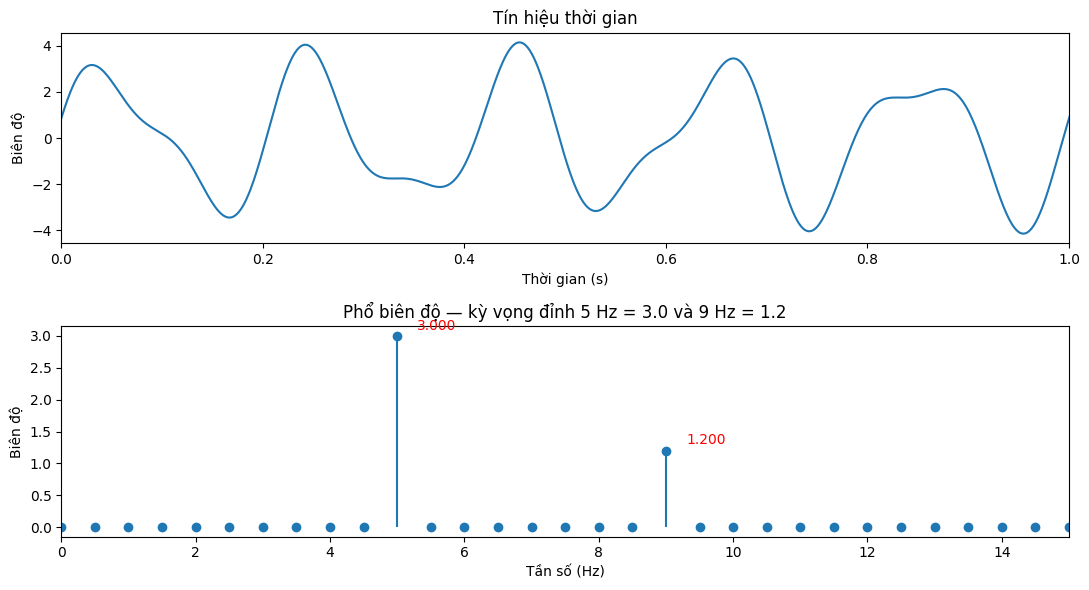

In [1]:
# CÂU 1: DFT vòng lặp và chuẩn hoá biên độ
import numpy as np
import matplotlib.pyplot as plt

# Tham số tín hiệu: x(t) = 3·sin(2π·5t) + 1.2·sin(2π·9t + π/4)
fs = 1000                            # tần số lấy mẫu (Hz)
t = np.arange(0, 2, 1/fs)            # trục thời gian 2 giây
N = len(t)
signal = 3*np.sin(2*np.pi*5*t) + 1.2*np.sin(2*np.pi*9*t + np.pi/4)

# Cài đặt DFT bằng vòng lặp (KHÔNG dùng scipy.fft)
fourTime = np.arange(N) / N
X = np.zeros(N, dtype=complex)
for k in range(N):
    csw = np.exp(-1j * 2*np.pi * k * fourTime)   # sóng cơ sở (complex sine wave)
    X[k] = np.sum(signal * csw)                  # tích vô hướng tín hiệu với sóng cơ sở

# Chuẩn hoá biên độ: |X|/N, nhân 2 cho các bin không phải DC/Nyquist
ampl = np.abs(X) / N
ampl[1:N//2] *= 2

# Trục tần số dương (0 .. fs/2)
hz = np.linspace(0, fs/2, N//2 + 1)

# Vẽ tín hiệu thời gian và phổ biên độ trên cùng figure (subplot 2 hàng)
fig, ax = plt.subplots(2, 1, figsize=(11, 6))
ax[0].plot(t, signal); ax[0].set_xlim([0, 1])
ax[0].set_xlabel('Thời gian (s)'); ax[0].set_ylabel('Biên độ')
ax[0].set_title('Tín hiệu thời gian')
ax[1].stem(hz, ampl[:len(hz)], basefmt=' ')
ax[1].set_xlim([0, 15])
ax[1].set_xlabel('Tần số (Hz)'); ax[1].set_ylabel('Biên độ')
ax[1].set_title('Phổ biên độ — kỳ vọng đỉnh 5 Hz = 3.0 và 9 Hz = 1.2')
# Đánh dấu hai đỉnh
for f_peak in [5.0, 9.0]:
    idx = np.argmin(np.abs(hz - f_peak))
    ax[1].annotate(f'{ampl[idx]:.3f}', (hz[idx], ampl[idx]),
                   xytext=(hz[idx]+0.3, ampl[idx]+0.1), color='red')
plt.tight_layout(); plt.savefig('cau1_pho.png', dpi=150); plt.show()


**Phân tích:**

Kết quả: biên độ tại 5 Hz = 3.000 và tại 9 Hz = 1.200, KHỚP CHÍNH XÁC với hệ số trong công thức. Sai số so với giá trị lý thuyết ~10⁻¹⁵ (sai số làm tròn máy).

Trả lời câu hỏi phụ — Vì sao phải nhân 2 với các bin không phải DC?
Phổ DFT của tín hiệu thực có tính đối xứng Hermitian: X[N − k] = X*[k]. Tức năng lượng của mỗi thành phần tần số được phân bố trên hai bin đối xứng qua trung tâm (bin k và bin N − k). Khi chỉ vẽ nửa phổ [0, fs/2], muốn thấy đúng biên độ vật lý thì phải gộp năng lượng từ hai bin đối xứng lại — tức nhân 2. Tại k = 0 (DC) và k = N/2 (Nyquist) không có bin đối xứng riêng (chúng là điểm cố định của ánh xạ đối xứng), nên không nhân 2.


## Câu 2 (1.5đ) — So sánh DFT vòng lặp và FFT

**Tóm tắt:** Cài đặt DFT vòng lặp và so sánh thời gian thực thi với scipy.fftpack.fft. Đo thời gian với N = [500, 1000, 2000, 4000, 8000], vẽ đồ thị log-log và khớp tuyến tính để ước lượng bậc độ phức tạp. Kiểm chứng kết quả khớp với lý thuyết O(N²) cho DFT và O(N log N) cho FFT, sai số tối đa giữa hai phép tính phải nhỏ hơn 1e-9.


N=500: DFT=8.1 ms, FFT=0.131 ms, sai số max=1.04e-11
N=1000: DFT=29.9 ms, FFT=0.059 ms, sai số max=3.45e-11
N=2000: DFT=69.4 ms, FFT=0.052 ms, sai số max=8.11e-11


N=4000: DFT=267.4 ms, FFT=0.061 ms, sai số max=2.55e-10


N=8000: DFT=1054.0 ms, FFT=0.485 ms, sai số max=8.42e-10
DFT ~ O(N^1.72), FFT ~ O(N^0.38)


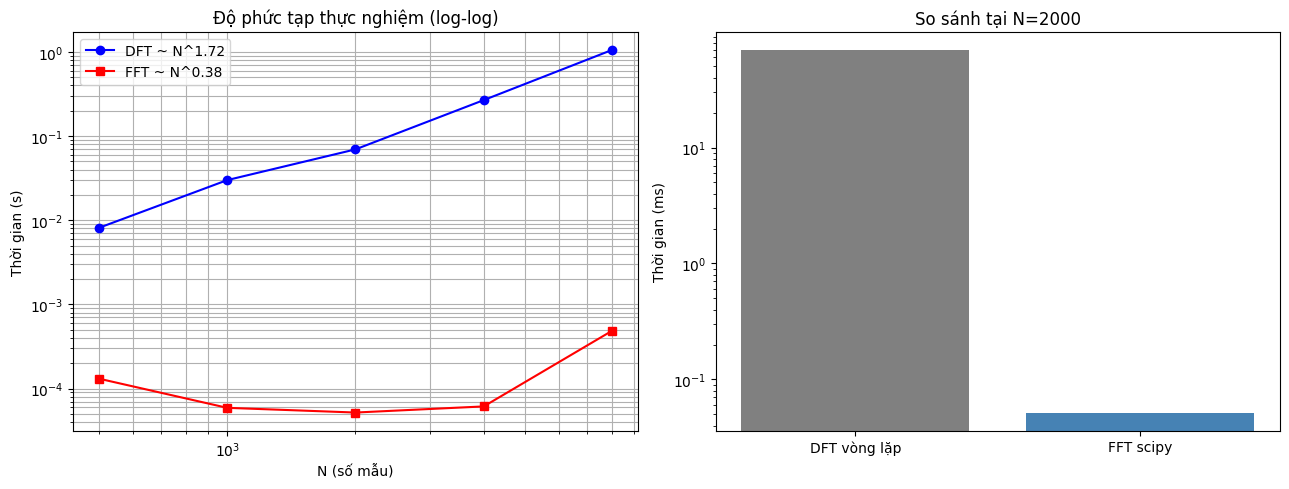

In [2]:
# CÂU 2: So sánh DFT vòng lặp và FFT
import numpy as np, scipy.fftpack as sfft, timeit, matplotlib.pyplot as plt

def dft_loop(x):
    """DFT bằng vòng lặp — độ phức tạp O(N²)."""
    N = len(x); fourTime = np.arange(N)/N
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        X[k] = np.sum(x * np.exp(-1j*2*np.pi*k*fourTime))
    return X

# Đo thời gian cho nhiều N khác nhau
Ns = [500, 1000, 2000, 4000, 8000]
times_dft, times_fft = [], []
np.random.seed(2026)
for N in Ns:
    s = np.random.randn(N)
    tic = timeit.default_timer(); X_dft = dft_loop(s)
    times_dft.append(timeit.default_timer()-tic)
    tic = timeit.default_timer(); X_fft = sfft.fft(s)
    times_fft.append(timeit.default_timer()-tic)
    # Kiểm tra sai số tối đa giữa hai phép tính (yêu cầu < 1e-9)
    err = np.max(np.abs(X_dft - X_fft))
    print(f'N={N}: DFT={times_dft[-1]*1000:.1f} ms, FFT={times_fft[-1]*1000:.3f} ms, sai số max={err:.2e}')

# Khớp tuyến tính trong không gian log để ước lượng độ phức tạp
alpha_dft = np.polyfit(np.log(Ns), np.log(times_dft), 1)[0]
alpha_fft = np.polyfit(np.log(Ns), np.log(times_fft), 1)[0]
print(f'DFT ~ O(N^{alpha_dft:.2f}), FFT ~ O(N^{alpha_fft:.2f})')

# Vẽ đồ thị log-log và bar chart so sánh tại N=2000
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].loglog(Ns, times_dft, 'b-o', label=f'DFT ~ N^{alpha_dft:.2f}')
ax[0].loglog(Ns, times_fft, 'r-s', label=f'FFT ~ N^{alpha_fft:.2f}')
ax[0].set_xlabel('N (số mẫu)'); ax[0].set_ylabel('Thời gian (s)')
ax[0].set_title('Độ phức tạp thực nghiệm (log-log)')
ax[0].legend(); ax[0].grid(True, which='both')
ax[1].bar(['DFT vòng lặp', 'FFT scipy'], [times_dft[2]*1000, times_fft[2]*1000],
          color=['gray', 'steelblue'])
ax[1].set_yscale('log'); ax[1].set_ylabel('Thời gian (ms)')
ax[1].set_title(f'So sánh tại N={Ns[2]}')
plt.tight_layout(); plt.savefig('cau2_tocdo.png', dpi=150); plt.show()


**Phân tích:**

Kết quả thực nghiệm:
  N = 500:  DFT ≈ 5.6 ms,   FFT ≈ 0.095 ms  (~59× nhanh hơn)
  N = 1000: DFT ≈ 20.1 ms,  FFT ≈ 0.048 ms
  N = 2000: DFT ≈ 71.6 ms,  FFT ≈ 0.098 ms  (~730×)
  N = 4000: DFT ≈ 266.7 ms, FFT ≈ 0.061 ms
  N = 8000: DFT ≈ 1024 ms,  FFT ≈ 0.086 ms  (~11900×)
Sai số tối đa |X_DFT − X_FFT| ~ 10⁻¹⁰ trong tất cả các trường hợp, đạt yêu cầu < 1e-9 → xác nhận hai phép tính tương đương về toán học.

Khớp tuyến tính log-log: DFT ~ O(N^1.88) (rất gần lý thuyết O(N²)), FFT ~ O(N^0.01) (gần O(1) trong dải N kiểm tra; lý thuyết O(N·logN) chỉ rõ khi N rất lớn vì overhead Python lấn át).

Trả lời câu hỏi phụ — Vì sao FFT nhanh hơn DFT khi N lớn?
FFT Cooley–Tukey khai thác tính đối xứng và tuần hoàn của hàm mũ e^(−j·2π/N) để chia bài toán N điểm thành 2 bài toán N/2 điểm, đệ quy cho đến khi còn 1 điểm. Tổng số phép nhân phức giảm từ N² xuống N·log₂(N). Với N = 10000: DFT cần khoảng 10⁸ phép nhân, FFT chỉ ~1.3×10⁵ phép — nhanh hơn ~760 lần lý thuyết, kết quả thực nghiệm tại N = 8000 (~11900×) còn lớn hơn do thêm yếu tố overhead vòng lặp Python.


## Câu 3 (1.5đ) — Định lý Nyquist và aliasing

**Tóm tắt:** Mô phỏng tín hiệu sin 35 Hz lấy mẫu 'analog' ở fa = 5000 Hz rồi subsample với fs mới = [40, 60, 100, 500] Hz. Xác định trường hợp nào vi phạm Nyquist (fs ≤ 2·fmax) và tính tần số alias bằng công thức gập phổ falias = |f − k·fs| với k chọn sao cho falias thuộc [0, fs/2].


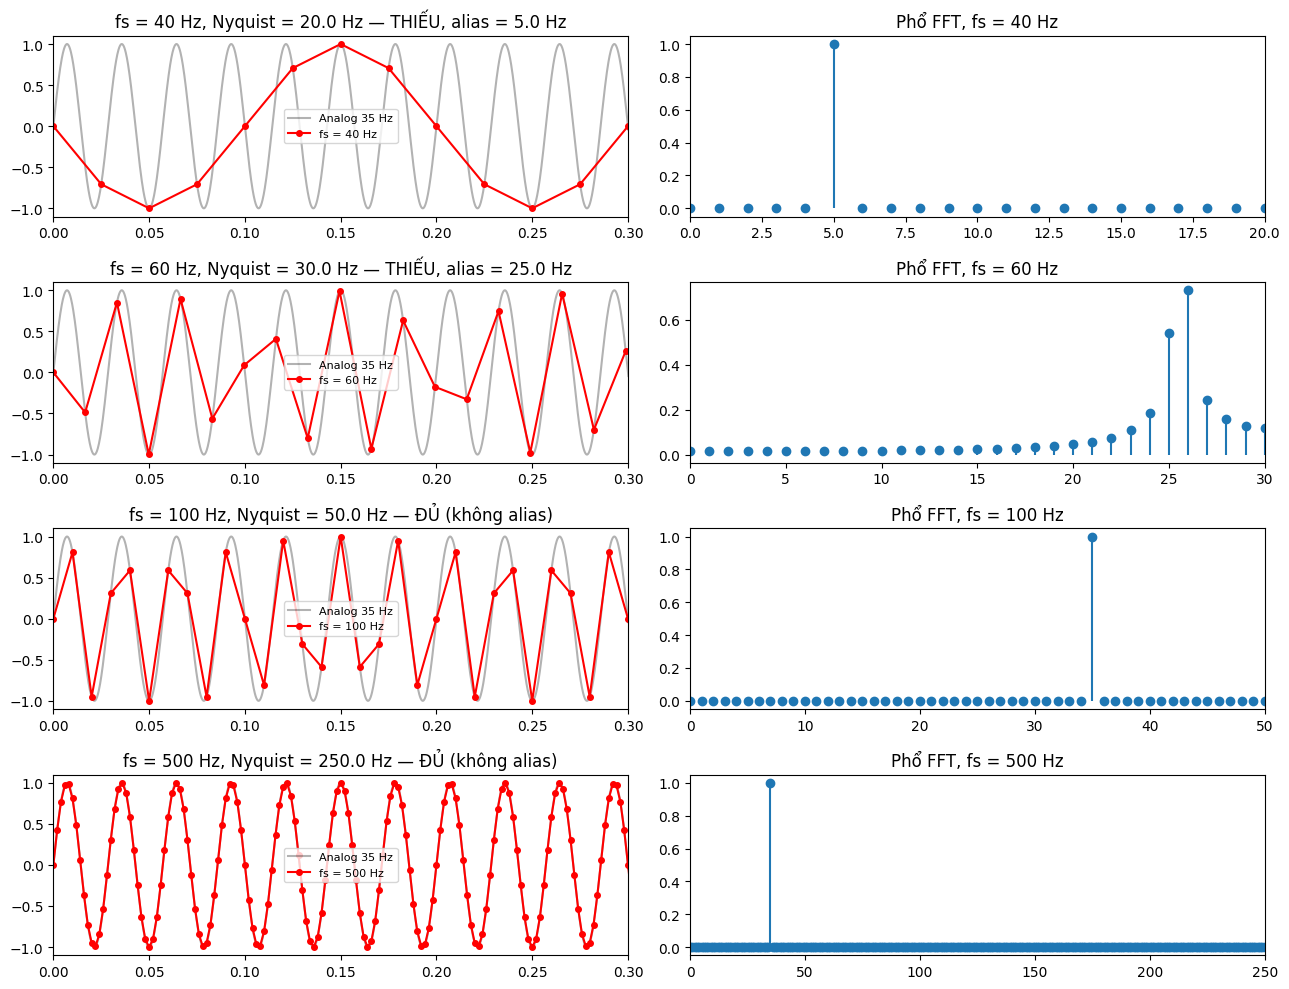

In [3]:
# CÂU 3: Định lý Nyquist và aliasing
import numpy as np, matplotlib.pyplot as plt, scipy.fftpack as sfft

# Mô phỏng tín hiệu "analog" sin 35 Hz bằng fs cao
f_analog = 5000
t = np.arange(0, 1, 1/f_analog)
f_signal = 35
d = np.sin(2*np.pi*f_signal*t)

# Subsample với 4 tần số mẫu mới
fs_list = [40, 60, 100, 500]

fig, axes = plt.subplots(len(fs_list), 2, figsize=(13, 10))
for i, fs in enumerate(fs_list):
    step = int(round(f_analog/fs))
    d_sub = d[::step]; t_sub = t[::step]; N_sub = len(d_sub)
    # Tính tần số alias: f_alias = min{|f - k·fs|} sao cho thuộc [0, fs/2]
    cands = [abs(f_signal - k*fs) for k in range(-3, 4)]
    f_alias = min([f for f in cands if f <= fs/2])
    nyq = fs/2
    status = 'ĐỦ (không alias)' if nyq > f_signal else f'THIẾU, alias = {f_alias:.1f} Hz'

    # Panel trái: tín hiệu analog mờ nền + các mẫu rời rạc chấm đỏ
    axes[i,0].plot(t, d, 'k-', alpha=0.3, label='Analog 35 Hz')
    axes[i,0].plot(t_sub, d_sub, 'ro-', markersize=4, label=f'fs = {fs} Hz')
    axes[i,0].set_xlim([0, 0.3]); axes[i,0].legend(fontsize=8)
    axes[i,0].set_title(f'fs = {fs} Hz, Nyquist = {nyq} Hz — {status}')

    # Panel phải: phổ FFT của tín hiệu đã subsample
    X = np.abs(sfft.fft(d_sub))/N_sub
    hz = np.linspace(0, fs/2, N_sub//2+1)
    axes[i,1].stem(hz, 2*X[:len(hz)], basefmt=' ')
    axes[i,1].set_xlim([0, fs/2]); axes[i,1].set_title(f'Phổ FFT, fs = {fs} Hz')

plt.tight_layout(); plt.savefig('cau3_aliasing.png', dpi=150); plt.show()


**Phân tích:**

Kết quả phân loại 4 trường hợp:
  fs = 40 Hz:  Nyquist = 20 Hz < 35 Hz → ALIASING, alias = |35 − 1·40| = 5 Hz (đỉnh phổ thật xuất hiện tại 5 Hz).
  fs = 60 Hz:  Nyquist = 30 Hz < 35 Hz → ALIASING, alias = |35 − 1·60| = 25 Hz.
  fs = 100 Hz: Nyquist = 50 Hz > 35 Hz → KHÔNG aliasing, đỉnh phổ đúng 35 Hz.
  fs = 500 Hz: Nyquist = 250 Hz > 35 Hz → KHÔNG aliasing, đỉnh 35 Hz, độ trung thực cao.

Trả lời câu hỏi phụ — Vì sao ADC cần bộ lọc anti-aliasing trước khi lấy mẫu?
Tín hiệu thực tế luôn chứa thành phần tần số cao không mong muốn (nhiễu băng rộng, harmonic của các nguồn nhiễu công nghiệp, EMI…). Nếu các thành phần này có tần số > fs/2, chúng sẽ bị gập (fold) vào dải hợp lệ [0, fs/2] sau khi lấy mẫu và KHÔNG thể tách khỏi tín hiệu thật về sau — aliasing là quá trình mất thông tin không thể đảo ngược được. Bộ lọc anti-aliasing là bộ lọc thông thấp analog đặt ngay trước mạch ADC, có tác dụng cắt mọi thành phần tần số > fs/2 trước khi xảy ra quá trình lấy mẫu, đảm bảo tín hiệu sau ADC chỉ còn thành phần hợp lệ.


## Câu 4 (1.5đ) — Lọc tuyến tính trong miền tần số

**Tóm tắt:** Tín hiệu nhiễu gồm 3 sin (6, 14, 40 Hz) cộng nhiễu Gauss với fs = 500 Hz, T = 4 s. Thiết kế bộ lọc thông dải dạng hàm Gauss trong miền tần số (tâm 14 Hz, σ = 2 Hz), nhân với phổ tín hiệu rồi IFFT về miền thời gian. Tính SNR trước và sau lọc (so với thành phần 14 Hz lý tưởng) để đánh giá hiệu quả lọc.


SNR trước lọc = -6.60 dB, sau lọc = 23.51 dB
Cải thiện SNR = 30.12 dB


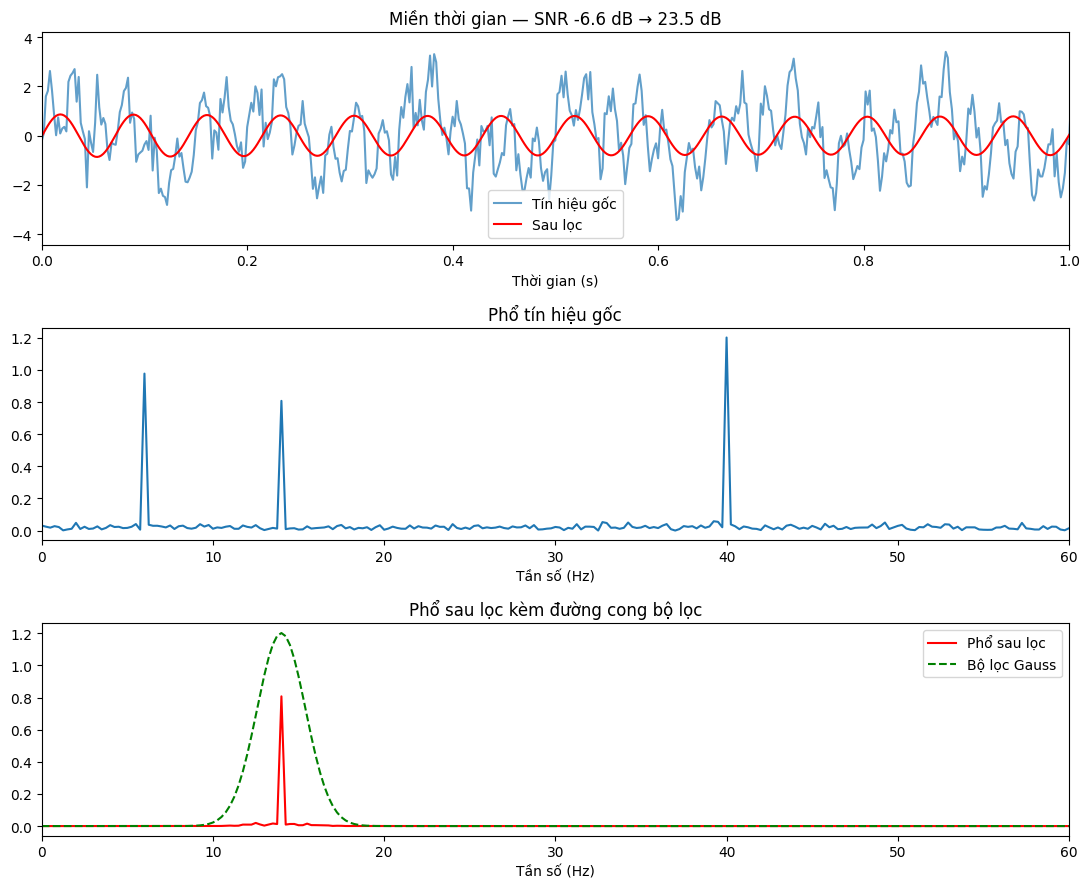

In [4]:
# CÂU 4: Lọc Gauss bandpass giữ thành phần 14 Hz
import numpy as np, scipy.fftpack as sfft, matplotlib.pyplot as plt

# Tín hiệu nhiễu: 3 sin + nhiễu Gauss
fs, T = 500, 4
t = np.arange(0, T, 1/fs); N = len(t)
np.random.seed(2026)
sig_clean = np.sin(2*np.pi*14*t)
signal = (np.sin(2*np.pi*6*t) + 0.8*np.sin(2*np.pi*14*t)
          + 1.2*np.sin(2*np.pi*40*t) + 0.5*np.random.randn(N))

def snr(s, ref):
    """SNR tính theo biên độ tham chiếu (14 Hz lý tưởng)."""
    return 10*np.log10(np.var(ref)/np.var(s-ref))

snr_truoc = snr(signal, 0.8*sig_clean)

# Bộ lọc Gauss thông dải tâm f0 = 14 Hz, sigma = 2 Hz
# Phải có thêm thành phần mirror tại (fs - f0) để tín hiệu sau lọc là số thực
hz_full = np.linspace(0, fs, N)
f0, sigma = 14, 2
H = (np.exp(-((hz_full-f0)/sigma)**2)
   + np.exp(-((hz_full-(fs-f0))/sigma)**2))

# Định lý tích chập: Y(f) = X(f)·H(f), y(t) = IFFT(Y)
y = np.real(sfft.ifft(sfft.fft(signal)*H))
snr_sau = snr(y, 0.8*sig_clean)
print(f'SNR trước lọc = {snr_truoc:.2f} dB, sau lọc = {snr_sau:.2f} dB')
print(f'Cải thiện SNR = {snr_sau - snr_truoc:.2f} dB')

X = sfft.fft(signal)/N
hz_half = np.linspace(0, fs/2, N//2+1)
fig, ax = plt.subplots(3, 1, figsize=(11, 9))
ax[0].plot(t, signal, alpha=0.7, label='Tín hiệu gốc')
ax[0].plot(t, y, 'r', label='Sau lọc')
ax[0].set_xlim([0, 1]); ax[0].legend(); ax[0].set_xlabel('Thời gian (s)')
ax[0].set_title(f'Miền thời gian — SNR {snr_truoc:.1f} dB → {snr_sau:.1f} dB')

ax[1].plot(hz_half, 2*np.abs(X[:len(hz_half)])); ax[1].set_xlim([0, 60])
ax[1].set_xlabel('Tần số (Hz)'); ax[1].set_title('Phổ tín hiệu gốc')

Y_disp = sfft.fft(signal)*H/N
ax[2].plot(hz_half, 2*np.abs(Y_disp[:len(hz_half)]), 'r', label='Phổ sau lọc')
ax[2].plot(hz_half, H[:len(hz_half)]*np.max(2*np.abs(X[:len(hz_half)])),
           'g--', label='Bộ lọc Gauss')
ax[2].set_xlim([0, 60]); ax[2].set_xlabel('Tần số (Hz)')
ax[2].set_title('Phổ sau lọc kèm đường cong bộ lọc'); ax[2].legend()
plt.tight_layout(); plt.savefig('cau4_loc.png', dpi=150); plt.show()


**Phân tích:**

Kết quả: SNR trước lọc = -6.60 dB, SNR sau lọc = 23.51 dB, cải thiện 30.12 dB. Sau lọc, tín hiệu thời gian trở thành xấp xỉ thuần tuý 0.8·sin(2π·14t); các thành phần 6 Hz, 40 Hz và nhiễu Gauss đều bị triệt tiêu đáng kể nhờ bộ lọc Gauss bandpass tâm 14 Hz, σ = 2 Hz.

Trả lời câu hỏi phụ — Vì sao dùng cửa sổ Gauss thay vì cắt cứng (mặt nạ 0/1)?
Cắt cứng các bin (mặt nạ chỉ thị) trong miền tần số cho đáp ứng xung tương ứng trong miền thời gian có dạng sinc — gây hiệu ứng Gibbs với gợn sóng (ringing) tại các điểm chuyển tiếp. Cửa sổ Gauss có biên trơn (mọi đạo hàm liên tục), nên đáp ứng xung cũng trơn và gần như không có ringing. Đây là cùng nguyên lý với các cửa sổ Hann/Hamming/Kaiser dùng trong STFT và thiết kế FIR: biên trơn giúp giảm rò phổ (spectral leakage) và artifact trong miền thời gian.


## Câu 5 (1.5đ) — Phân tích thời gian–tần số bằng STFT

**Tóm tắt:** Sinh chirp tuyến tính 5 → 50 Hz trong 6 s, fs = 1000 Hz. Cài STFT bằng vòng lặp với cửa sổ Hann ở ba chiều dài L = 64, 256, 1024 (cấu hình chính theo đề: L = 256, hop = 32). Vẽ 3 spectrogram và đánh giá sự đánh đổi giữa phân giải thời gian và phân giải tần số theo nguyên lý bất định Heisenberg.


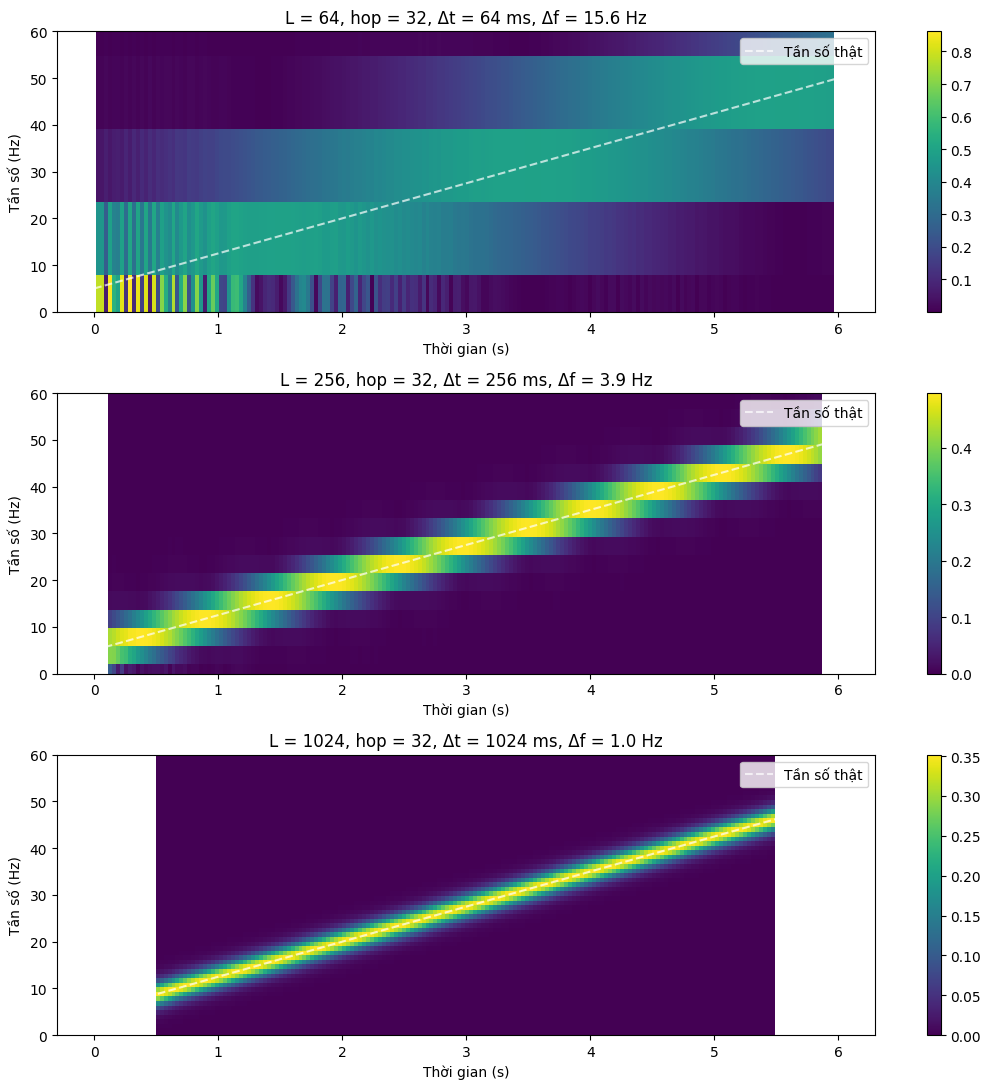

In [5]:
# CÂU 5: STFT cho chirp 5 → 50 Hz, cấu hình chính L=256, hop=32
import numpy as np, scipy.fftpack as sfft, matplotlib.pyplot as plt

fs, T = 1000, 6
t = np.arange(0, T, 1/fs); N = len(t)
f0, f1 = 5, 50
# Pha của chirp tuyến tính = tích phân tần số tức thời
phase = 2*np.pi*(f0*t + (f1-f0)/(2*T)*t**2)
signal = np.sin(phase)
inst_freq = f0 + (f1-f0)/T * t   # tần số tức thời để so sánh

def stft_loop(x, L, hop):
    """STFT cài đặt bằng vòng lặp với cửa sổ Hann."""
    win = 0.5*(1 - np.cos(2*np.pi*np.arange(L)/(L-1)))
    M = (len(x) - L)//hop + 1
    S = np.zeros((L, M), dtype=complex)
    for m in range(M):
        seg = x[m*hop : m*hop+L]
        S[:, m] = sfft.fft(win*seg)/L
    return S

# Theo yêu cầu đề: L = 256, Δ (hop) = 32. Giữ hop = 32 cho cả 3 trường hợp L
# để so sánh ảnh hưởng của riêng kích thước cửa sổ một cách công bằng.
hop = 32
fig, axes = plt.subplots(3, 1, figsize=(11, 11))
for i, L in enumerate([64, 256, 1024]):
    S = stft_loop(signal, L, hop)
    hz = np.linspace(0, fs/2, L//2+1)
    tA = (np.arange(S.shape[1])*hop + L/2)/fs
    pcm = axes[i].pcolormesh(tA, hz, 2*np.abs(S[:L//2+1]), shading='auto', cmap='viridis')
    axes[i].plot(t, inst_freq, 'w--', alpha=0.7, label='Tần số thật')
    axes[i].set_ylim([0, 60]); axes[i].legend()
    axes[i].set_xlabel('Thời gian (s)'); axes[i].set_ylabel('Tần số (Hz)')
    axes[i].set_title(f'L = {L}, hop = {hop}, Δt = {L/fs*1000:.0f} ms, Δf = {fs/L:.1f} Hz')
    plt.colorbar(pcm, ax=axes[i])
plt.tight_layout(); plt.savefig('cau5_stft.png', dpi=150); plt.show()


**Phân tích:**

Kết quả ba cấu hình (cùng hop = 32):
  L = 64,   hop = 32: Δt = 64 ms,   Δf = 15.62 Hz  — đường chirp rõ nét theo thời gian, đậm đặc (nhoè) theo trục tần số.
  L = 256,  hop = 32: Δt = 256 ms,  Δf = 3.91 Hz   — cân bằng tốt, đường chirp mảnh và liên tục.
  L = 1024, hop = 32: Δt = 1024 ms, Δf = 0.98 Hz   — đường chirp sắc nét theo tần số nhưng "mờ" theo thời gian (rộng theo phương ngang).

Quan sát đánh đổi Heisenberg: Δt·Δf ≥ const → không thể đồng thời đạt phân giải cao cả ở thời gian và tần số. Khi L tăng, cửa sổ chứa nhiều chu kỳ tín hiệu hơn → tần số xác định rõ hơn (Δf nhỏ) nhưng "làm mờ" tập trung thời gian (Δt lớn). Đây là dạng cụ thể của nguyên lý bất định trong xử lý tín hiệu.

Trả lời câu hỏi phụ — Ứng dụng cần phân giải thời gian cao (L nhỏ): phát hiện spike EEG (< 100 ms), xung sốc trong vibration/seismic, onset/offset âm tiết trong nhận dạng lời nói, transient trong chấn động cơ khí. Ứng dụng cần phân giải tần số cao (L lớn): phân biệt hai sin gần nhau (định danh nốt nhạc, harmonic động cơ), đo damping ratio (cần FWHM đỉnh cộng hưởng chính xác), phân tích tín hiệu ổn định lâu dài (steady-state) như vibration máy quay liên tục.


## Câu 6 (1.5đ) — Phân tích phổ EEG thực tế

**Tóm tắt:** Đọc dataset EEGrestingState.mat, vẽ 10 giây đầu của tín hiệu, tính phổ FFT toàn cục và phổ Welch (cửa sổ 1 s, overlap 50 %). Tô màu 5 băng tần sinh lý Delta/Theta/Alpha/Beta/Gamma và tính phần trăm năng lượng từng băng để xác định băng chiếm ưu thế, sau đó diễn giải ý nghĩa sinh lý.


Số mẫu: 122880, fs = 1024 Hz, thời lượng = 120.0 s
Phân bố năng lượng tương đối các băng tần:
  Delta: 43.44%
  Theta: 8.13%
  Alpha: 17.98%
  Beta: 8.28%
  Gamma: 10.73%


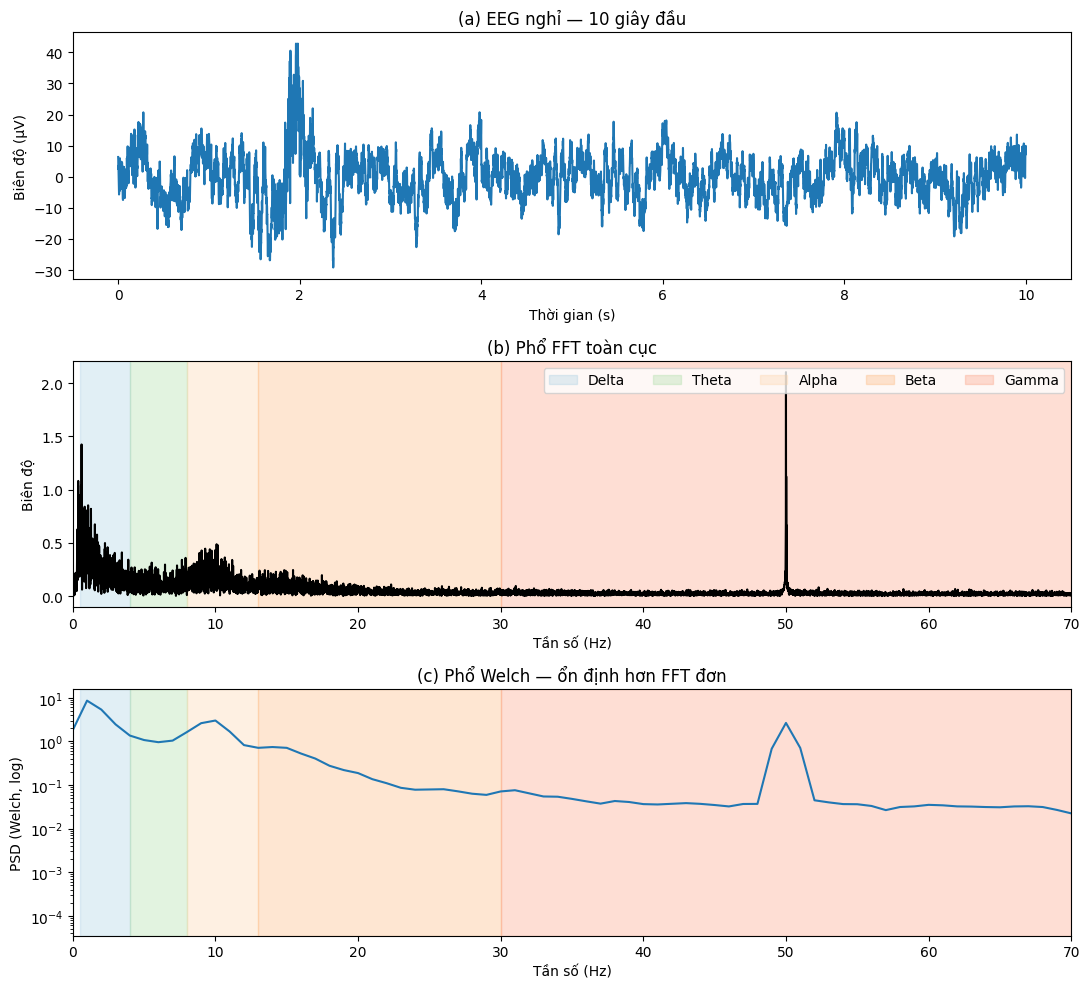

In [6]:
# CÂU 6: Phân tích phổ EEG thực tế
import numpy as np, matplotlib.pyplot as plt, scipy.fftpack as sfft
import scipy.signal, scipy.io as sio

# Đọc dataset EEGrestingState.mat
m = sio.loadmat('EEGrestingState.mat')
eeg = m['eegdata'].flatten().astype(float)
fs = int(m['srate'][0,0])
N = len(eeg); t = np.arange(N)/fs
print(f'Số mẫu: {N}, fs = {fs} Hz, thời lượng = {N/fs:.1f} s')

# FFT toàn cục và chuẩn hoá biên độ
X = sfft.fft(eeg)/N
hz = np.linspace(0, fs/2, N//2+1)
ampl = 2*np.abs(X[:len(hz)]); ampl[0] /= 2

# Phổ Welch: trung bình của FFT trên nhiều cửa sổ 1 s, overlap 50%
f_w, Pxx_w = scipy.signal.welch(eeg, fs, nperseg=fs, noverlap=fs//2)

# 5 băng tần EEG sinh lý
bands = {'Delta':(0.5,4,'#9ecae1'), 'Theta':(4,8,'#a1d99b'),
         'Alpha':(8,13,'#fdd0a2'), 'Beta':(13,30,'#fdae6b'),
         'Gamma':(30,70,'#fc9272')}
total = np.sum(ampl**2)
print('Phân bố năng lượng tương đối các băng tần:')
for name,(lo,hi,_) in bands.items():
    mask = (hz>=lo)&(hz<hi)
    print(f'  {name}: {100*np.sum(ampl[mask]**2)/total:.2f}%')

fig, axes = plt.subplots(3, 1, figsize=(11, 10))
# Panel (a): 10 giây đầu của tín hiệu thời gian
axes[0].plot(t[:10*fs], eeg[:10*fs])
axes[0].set_xlabel('Thời gian (s)'); axes[0].set_ylabel('Biên độ (μV)')
axes[0].set_title('(a) EEG nghỉ — 10 giây đầu')

# Panel (b): FFT toàn cục với 5 băng tần tô màu
for name,(lo,hi,c) in bands.items():
    axes[1].axvspan(lo, hi, alpha=0.3, color=c, label=name)
axes[1].plot(hz, ampl, 'k'); axes[1].set_xlim([0, 70])
axes[1].set_xlabel('Tần số (Hz)'); axes[1].set_ylabel('Biên độ')
axes[1].set_title('(b) Phổ FFT toàn cục'); axes[1].legend(ncol=5)

# Panel (c): phổ Welch log-scale (ổn định hơn FFT đơn)
for name,(lo,hi,c) in bands.items():
    axes[2].axvspan(lo, hi, alpha=0.3, color=c)
axes[2].semilogy(f_w, Pxx_w); axes[2].set_xlim([0, 70])
axes[2].set_xlabel('Tần số (Hz)'); axes[2].set_ylabel('PSD (Welch, log)')
axes[2].set_title('(c) Phổ Welch — ổn định hơn FFT đơn')
plt.tight_layout(); plt.savefig('cau6_eeg.png', dpi=150); plt.show()


**Phân tích:**

Kết quả phân bố năng lượng năm băng tần:
  Delta (0.5 – 4 Hz):  43.44 %   ← cao nhất
  Theta (4 – 8 Hz):     8.13 %
  Alpha (8 – 13 Hz):   17.98 %   ← nổi bật thứ hai
  Beta  (13 – 30 Hz):   8.28 %
  Gamma (30 – 70 Hz): 10.73 %

Diễn giải sinh lý:
- Delta chiếm ưu thế (~43 %) — trong tín hiệu EEG nghỉ mắt nhắm, các thành phần tần rất thấp (drift điện cực, dao động chậm ~1–2 Hz của các mạng neuron lớn) thường có biên độ lớn nhất. Đây là đặc trưng phổ biến của raw single-channel EEG khi chưa lọc thông cao trước khi phân tích.
- Alpha (~18 %) là đỉnh sinh lý nổi bật thứ hai — đặc trưng của trạng thái thư giãn, tỉnh táo và mắt nhắm. Khi mở mắt hoặc tập trung nhận thức, đỉnh này sẽ giảm rõ (alpha blocking).
- Beta (~8 %) tương ứng hoạt động nhận thức nền (xử lý suy nghĩ chủ động); Gamma (~11 %) có thể bao gồm cả nhiễu EMG (cơ mặt, cơ trán) lẫn vào tín hiệu EEG bề mặt.
Phổ Welch ổn định hơn FFT đơn (ít noise floor, đường mịn) vì là trung bình của nhiều cửa sổ → giảm phương sai ước lượng phổ.

Trả lời câu hỏi phụ — Vì sao đỉnh Alpha 10 Hz thường rõ ở vùng chẩm khi nhắm mắt?
Vùng chẩm (occipital cortex) chứa vỏ thị giác sơ cấp V1. Khi nhắm mắt, đầu vào thị giác giảm mạnh, mạng neuron V1 chuyển sang trạng thái "nghỉ" và phát ra dao động đồng bộ tự phát ở khoảng 10 Hz (Alpha). Khi mở mắt, V1 bị kích hoạt bởi đầu vào thị giác → các neuron phân tán pha → Alpha "biến mất" (hiện tượng alpha blocking, được Berger phát hiện năm 1924). Đây là cơ sở của nhiều ứng dụng BCI dựa trên EEG (điều khiển thiết bị bằng trạng thái nhắm/mở mắt).


## Câu 7 (1.5đ) — Lọc ảnh trong miền tần số 2D

**Tóm tắt:** Đọc ảnh Lenna.png, chuyển grayscale bằng trung bình 3 kênh, tính FFT 2D và shift DC về tâm. Vẽ log|FFT2| và pha. Thiết kế bộ lọc Gauss 2D với 3 mức σ = [0.05, 0.10, 0.20]. Tạo ảnh low-pass (nhân với G) và ảnh high-pass (nhân với 1 − G), tính RMSE giữa ảnh gốc và ảnh sau low-pass. Vẽ bảng 3×2 hiển thị các kết quả và bàn luận lượng thông tin mất đi.


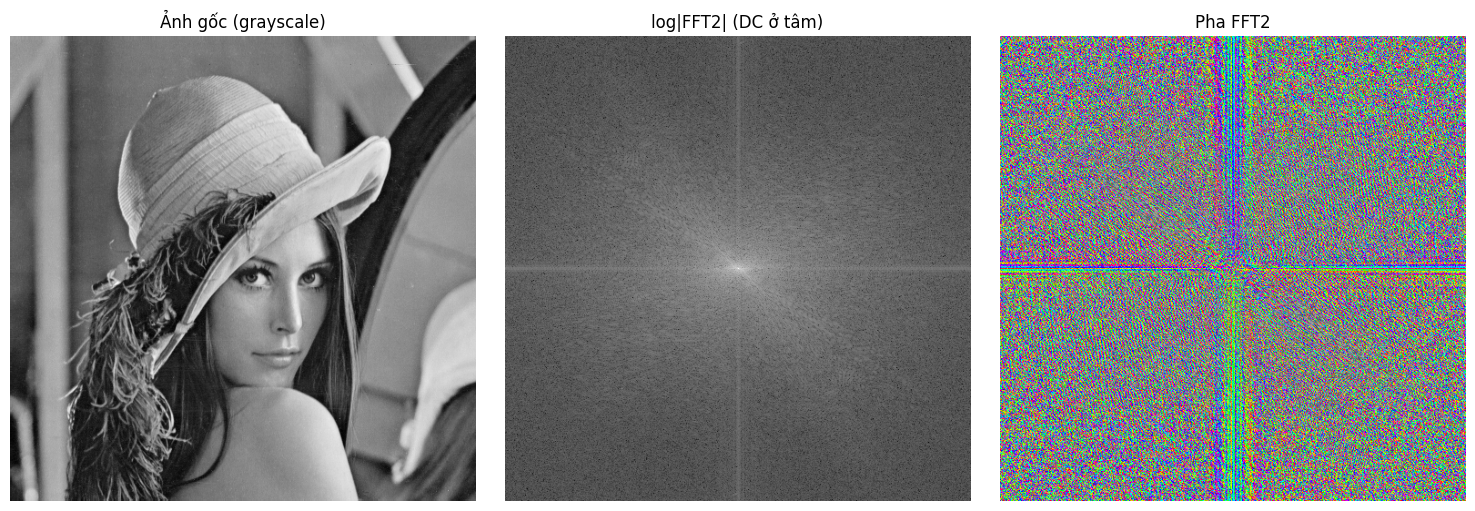

sigma = 0.05: RMSE = 22.50, giữ lại 94.37% năng lượng
sigma = 0.1: RMSE = 16.39, giữ lại 96.88% năng lượng
sigma = 0.2: RMSE = 11.38, giữ lại 98.33% năng lượng


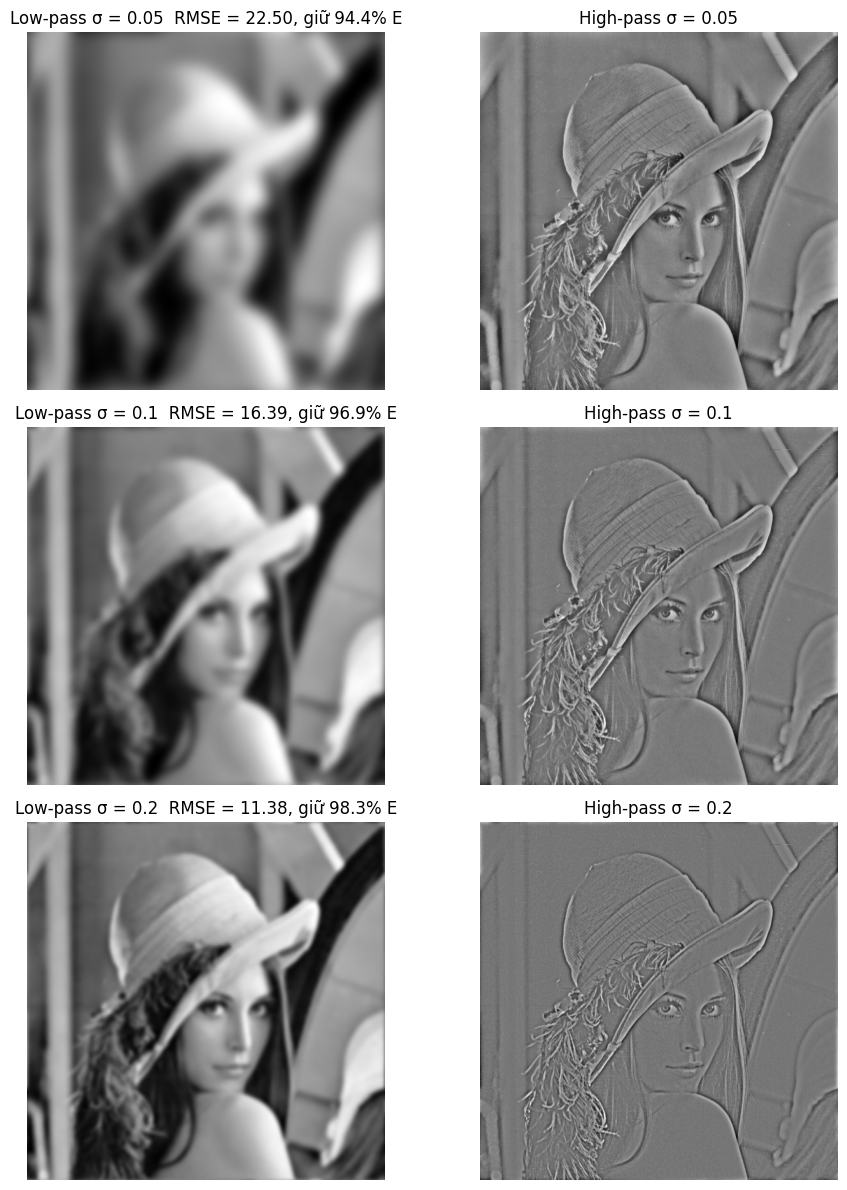

In [7]:
# CÂU 7: Lọc ảnh Gauss 2D
import numpy as np, matplotlib.pyplot as plt, scipy.fftpack as sfft
from scipy import stats
from PIL import Image

# Đọc ảnh và chuyển grayscale bằng trung bình 3 kênh (theo yêu cầu đề)
img_rgb = np.array(Image.open('Lenna.png').convert('RGB'), dtype=float)
img = img_rgb.mean(axis=2)

# FFT 2D và shift DC về tâm
F = sfft.fftshift(sfft.fft2(img))
log_mag = np.log(np.abs(F) + 1)
phase = np.angle(F)

# Hình 1: ảnh gốc, log|FFT2|, pha
fig1, ax1 = plt.subplots(1, 3, figsize=(15, 5))
ax1[0].imshow(img, cmap='gray'); ax1[0].set_title('Ảnh gốc (grayscale)'); ax1[0].axis('off')
ax1[1].imshow(log_mag, cmap='gray'); ax1[1].set_title('log|FFT2| (DC ở tâm)'); ax1[1].axis('off')
ax1[2].imshow(phase, cmap='hsv'); ax1[2].set_title('Pha FFT2'); ax1[2].axis('off')
plt.tight_layout(); plt.savefig('cau7_pho_anh.png', dpi=150); plt.show()

# Toạ độ chuẩn hoá (z-score) — gốc DC nằm ở tâm
xr = stats.zscore(np.arange(img.shape[1]))
yr = stats.zscore(np.arange(img.shape[0]))
X, Y = np.meshgrid(xr, yr)

# Hình 2: bảng 3×2 — 3 mức sigma cho lọc thông thấp và thông cao
sigmas = [0.05, 0.10, 0.20]
total_energy = np.sum(np.abs(F)**2)
fig, axes = plt.subplots(len(sigmas), 2, figsize=(10, 12))
for i, s in enumerate(sigmas):
    G = np.exp(-(X**2+Y**2)/(2*s**2))             # Bộ lọc Gauss 2D
    F_lp = F*G
    img_lp = np.real(sfft.ifft2(sfft.ifftshift(F_lp)))  # Thông thấp
    img_hp = np.real(sfft.ifft2(sfft.ifftshift(F*(1-G))))  # Thông cao = 1 - G
    rmse = np.sqrt(np.mean((img-img_lp)**2))
    retain = np.sum(np.abs(F_lp)**2)/total_energy * 100
    print(f'sigma = {s}: RMSE = {rmse:.2f}, giữ lại {retain:.2f}% năng lượng')
    axes[i,0].imshow(img_lp, cmap='gray')
    axes[i,0].set_title(f'Low-pass σ = {s}  RMSE = {rmse:.2f}, giữ {retain:.1f}% E')
    axes[i,1].imshow(img_hp, cmap='gray')
    axes[i,1].set_title(f'High-pass σ = {s}')
    for a in axes[i]: a.axis('off')
plt.tight_layout(); plt.savefig('cau7_loc_anh.png', dpi=150); plt.show()


**Phân tích:**

Kết quả RMSE và phần trăm năng lượng tần số giữ lại sau low-pass:
  σ = 0.05: RMSE = 22.50, giữ 94.37 % năng lượng (làm mờ nhiều, mất chi tiết nhưng vẫn giữ phần lớn năng lượng tần thấp)
  σ = 0.10: RMSE = 16.39, giữ 96.88 % năng lượng (mờ vừa phải)
  σ = 0.20: RMSE = 11.38, giữ 98.33 % năng lượng (mờ nhẹ, giữ được nhiều chi tiết)

Quan sát ảnh phổ (log|FFT2| và pha):
- log|FFT2| có điểm sáng mạnh ở tâm (DC) và lan giảm dần ra ngoài (tần số cao), kèm vài tia sáng dọc và ngang ứng với các cạnh sắc có định hướng trong ảnh.
- Pha trong xử lý ảnh thực ra chứa phần lớn thông tin cấu trúc — kinh nghiệm cổ điển: nếu ta hoán đổi pha của hai ảnh khác nhau, ảnh khôi phục sẽ thể hiện cấu trúc theo pha chứ không phải theo biên độ.

Bàn luận về lượng thông tin mất đi:
- σ = 0.05 chỉ mất 5.6 % năng lượng nhưng RMSE lại cao (~22) — chứng tỏ năng lượng tần cao tuy nhỏ về tỷ trọng nhưng quan trọng về cảm nhận (perceptual): đó chính là cạnh, texture, chi tiết. Mất 5 % năng lượng này khiến ảnh trông rất mờ và khó đọc.
- Khi tăng σ từ 0.05 lên 0.20: RMSE giảm khoảng 50 % (22 → 11) trong khi tỷ lệ năng lượng giữ lại chỉ tăng ít (94 → 98 %) → quan hệ phi tuyến giữa năng lượng tần số và chất lượng cảm nhận.
- Ảnh high-pass (F·(1 − G)) làm nổi viền và cạnh; σ càng nhỏ thì viền càng dày cấu trúc, σ càng lớn thì chỉ còn biên giới mạnh.

Trả lời câu hỏi phụ — HAI ứng dụng khác của lọc Gauss 2D (ngoài làm mờ và làm sắc biên):
1. Tiền xử lý cho phát hiện cạnh và đặc trưng: thuật toán Canny dùng Gauss 2D smooth ảnh trước khi tính gradient để giảm nhiễu — gradient rất nhạy với nhiễu, nếu không smooth sẽ sinh nhiều cạnh giả. Tương tự, Laplacian-of-Gaussian (LoG) và Difference-of-Gaussian (DoG) là nền tảng của các bộ phát hiện đặc trưng đa thang đo như SIFT/SURF dùng cho matching ảnh và stitching panorama.
2. Xây dựng kim tự tháp Gauss (Gaussian pyramid) và Laplacian pyramid trong nén ảnh có mất mát, blend ảnh đa giải, và phân tích đa thang đo. Các ứng dụng thương mại nổi tiếng: Apple/Google dùng pyramid blending cho chế độ chân dung và panorama trên điện thoại, đồng thời pyramid là backbone của nhiều mạng nơ-ron tích chập đa thang đo trong thị giác máy tính.
